Image size: 1920x1200 (WxH)
Optical center (from calibration): cx=959.68, cy=597.46

This is a circular fisheye FOV cropped by a rectangular sensor:
  - The circle radius > 600px (extends beyond top/bottom)
  - Four corners have BLACK regions (outside fisheye circle)


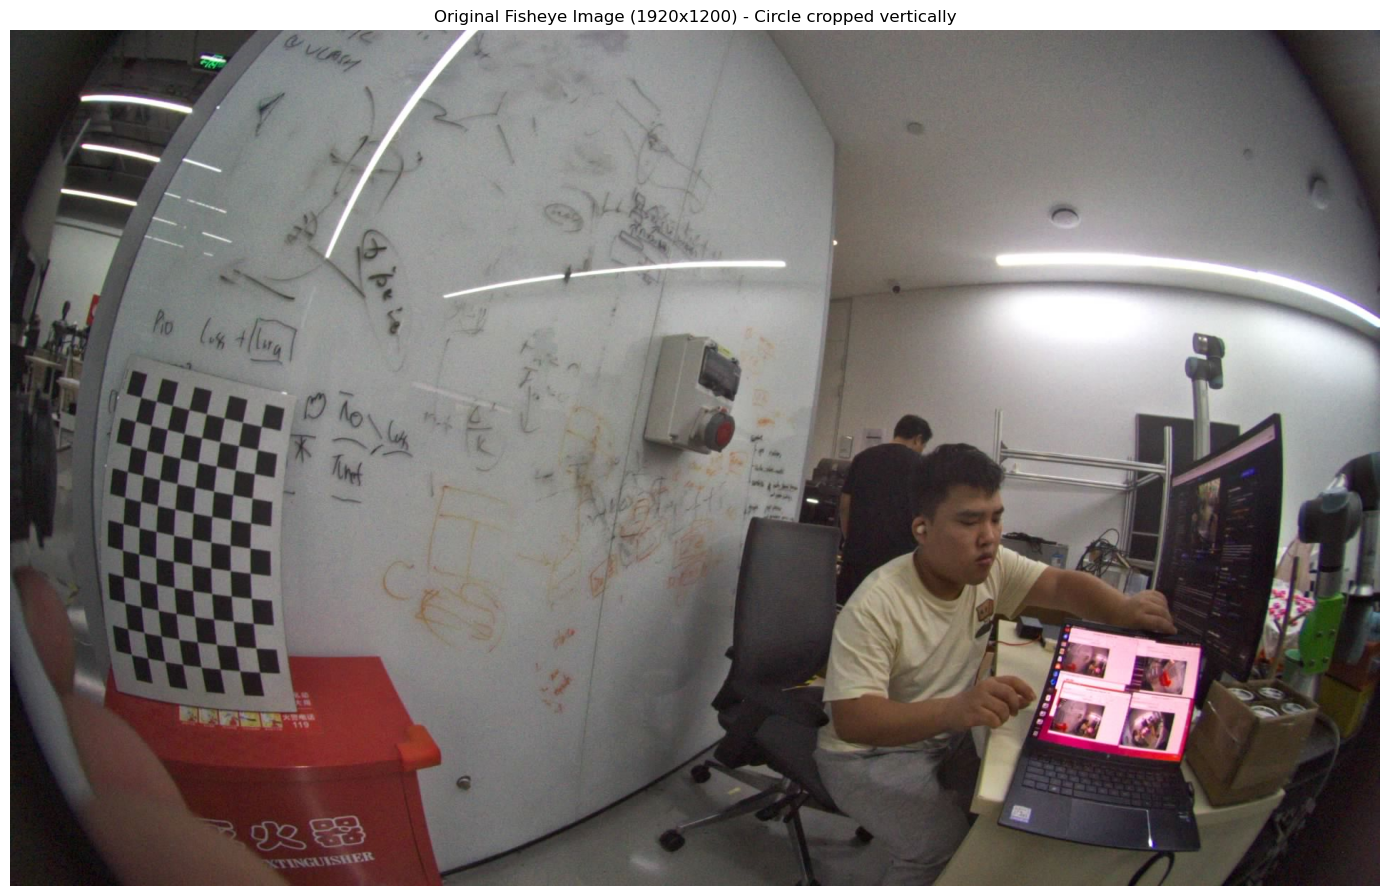

In [91]:
# Step 1: Load and display the original fisheye image
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = '/home/lhk/workspace/VINS-Fisheye/config/my_kalibr_fisheye/1779267025819498841.png'
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

h, w = gray.shape
print(f"Image size: {w}x{h} (WxH)")
print(f"Optical center (from calibration): cx=959.68, cy=597.46")
print(f"\nThis is a circular fisheye FOV cropped by a rectangular sensor:")
print(f"  - The circle radius > {h//2}px (extends beyond top/bottom)")
print(f"  - Four corners have BLACK regions (outside fisheye circle)")

plt.figure(figsize=(14, 9))
plt.imshow(img_rgb)
plt.title(f'Original Fisheye Image ({w}x{h}) - Circle cropped vertically')
plt.axis('off')
plt.tight_layout()
plt.show()

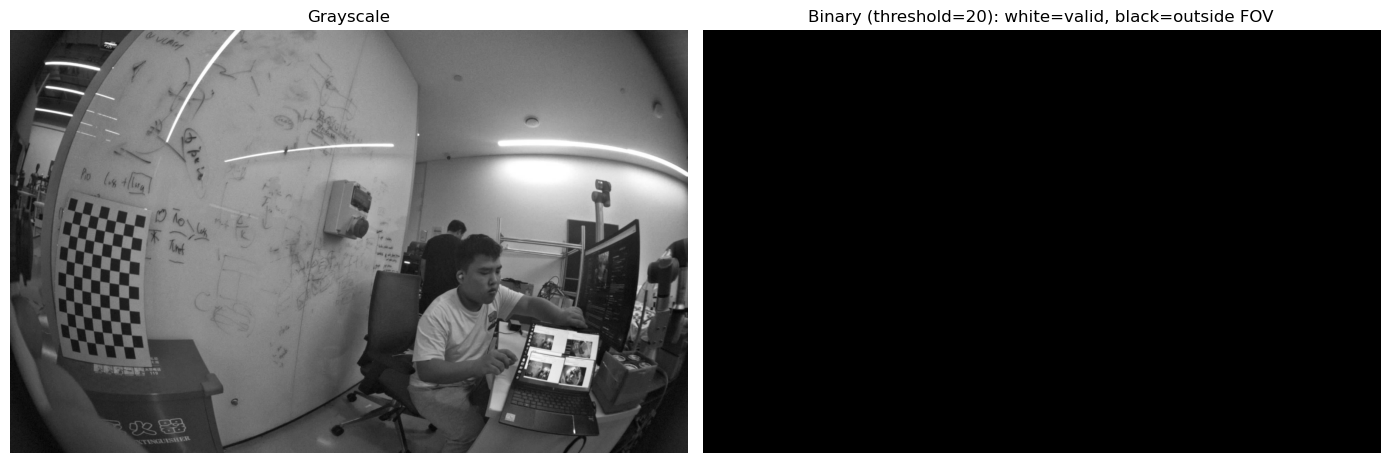

Corner mean brightness (should be very dark if outside FOV):
  Top-Left: mean=36.4, max=157
  Top-Right: mean=60.5, max=94
  Bottom-Left: mean=21.0, max=41
  Bottom-Right: mean=28.7, max=57


In [92]:
# Step 2: Detect the dark corners to find the fisheye circle boundary
# The four corners are black (outside the circular FOV)

# Threshold to find dark pixels
_, binary = cv2.threshold(gray, 20, 255, cv2.THRESH_BINARY)

# Clean up with morphology
kernel = np.ones((7, 7), np.uint8)
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=5)
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=3)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary, cmap='gray')
plt.title('Binary (threshold=20): white=valid, black=outside FOV')
plt.axis('off')
plt.tight_layout()
plt.show()

# Check the corners specifically
corner_size = 100
corners = {
    'Top-Left': gray[:corner_size, :corner_size],
    'Top-Right': gray[:corner_size, -corner_size:],
    'Bottom-Left': gray[-corner_size:, :corner_size],
    'Bottom-Right': gray[-corner_size:, -corner_size:],
}
print("Corner mean brightness (should be very dark if outside FOV):")
for name, corner in corners.items():
    print(f"  {name}: mean={corner.mean():.1f}, max={corner.max()}")

Method 1 - Min enclosing circle: center=(959.5, 599.5), r=1131.4px
Method 2 - From calibration center + left/right edges: center=(959.7, 597.5), r=1131.4px

Using Method 2 (calibration center is more accurate)


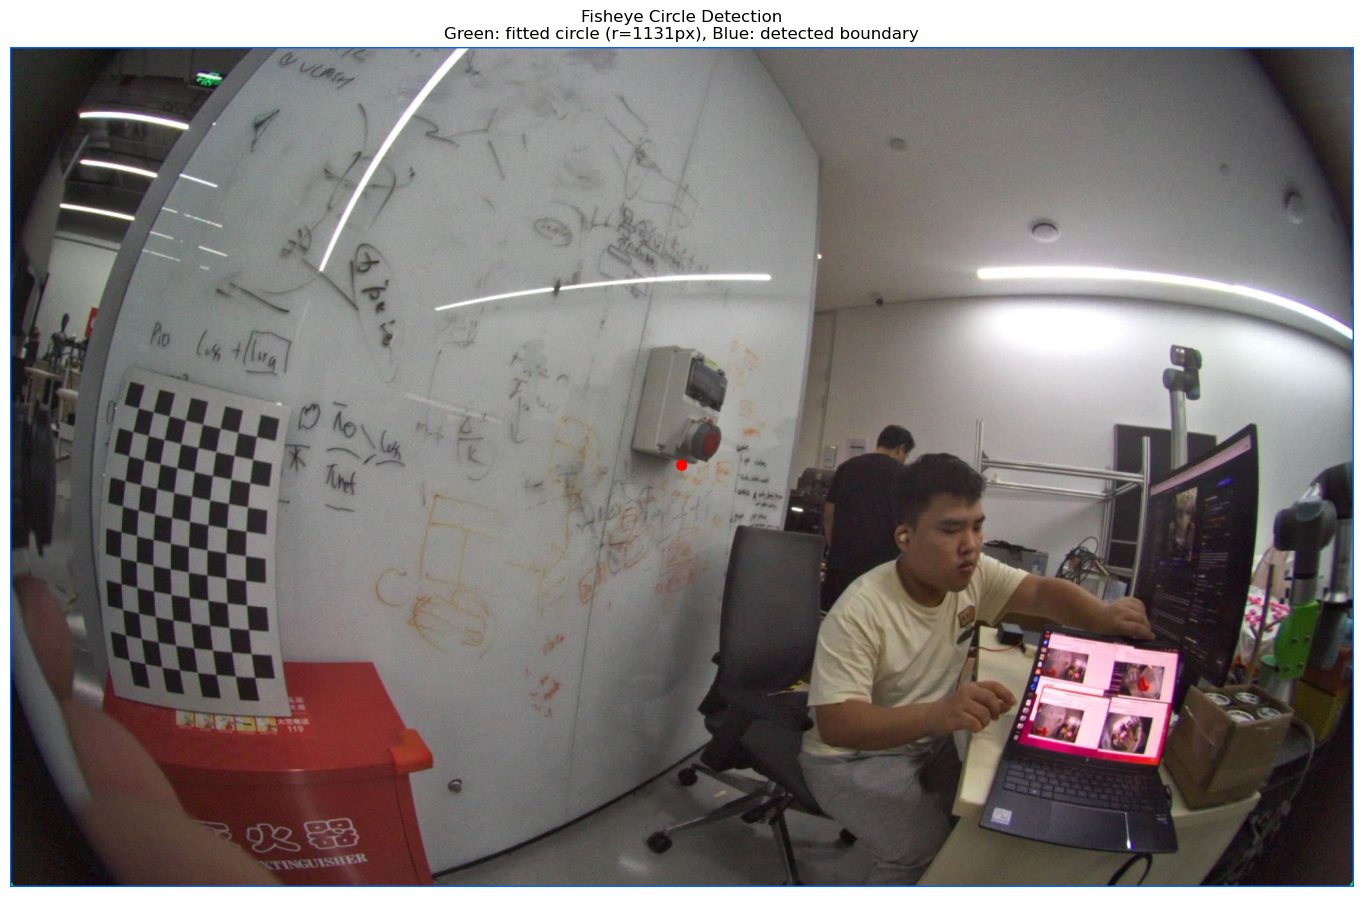

In [93]:
# Step 3: Fit a circle to the boundary between valid/invalid regions
# Use the contour of the binary mask to fit the fisheye circle

# Find the boundary contour of the valid region
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)

# Method 1: Minimum enclosing circle
(cx_fit, cy_fit), radius_fit = cv2.minEnclosingCircle(largest_contour)

# Method 2: Use optical center from calibration and find radius
# Since we know the optical center precisely from DS calibration:
cx_cam, cy_cam = 959.68, 597.46

# Compute radius as the average distance from center to contour boundary points
distances = []
for pt in largest_contour:
    x, y = pt[0]
    d = np.sqrt((x - cx_cam)**2 + (y - cy_cam)**2)
    distances.append(d)

# The max distance in the contour is approximately the circle radius
# But since the circle is clipped top/bottom, only the LEFT and RIGHT edges give true radius
# Filter: only use points near the left/right edges (y close to cy_cam)
edge_distances = []
for pt in largest_contour:
    x, y = pt[0]
    # Only consider points near the horizontal center line (within ±50px of cy)
    if abs(y - cy_cam) < 50:
        d = np.sqrt((x - cx_cam)**2 + (y - cy_cam)**2)
        edge_distances.append(d)

if edge_distances:
    radius_from_edges = np.mean(edge_distances)
else:
    radius_from_edges = radius_fit

print(f"Method 1 - Min enclosing circle: center=({cx_fit:.1f}, {cy_fit:.1f}), r={radius_fit:.1f}px")
print(f"Method 2 - From calibration center + left/right edges: center=({cx_cam:.1f}, {cy_cam:.1f}), r={radius_from_edges:.1f}px")
print(f"\nUsing Method 2 (calibration center is more accurate)")

# Visualize
vis = img_rgb.copy()
# Draw fitted circle (green)
cv2.circle(vis, (int(cx_cam), int(cy_cam)), int(radius_from_edges), (0, 255, 0), 3)
# Draw center
cv2.circle(vis, (int(cx_cam), int(cy_cam)), 8, (255, 0, 0), -1)
# Draw the contour (blue)
cv2.drawContours(vis, [largest_contour], -1, (0, 100, 255), 2)

plt.figure(figsize=(14, 9))
plt.imshow(vis)
plt.title(f'Fisheye Circle Detection\nGreen: fitted circle (r={radius_from_edges:.0f}px), Blue: detected boundary')
plt.axis('off')
plt.tight_layout()
plt.show()

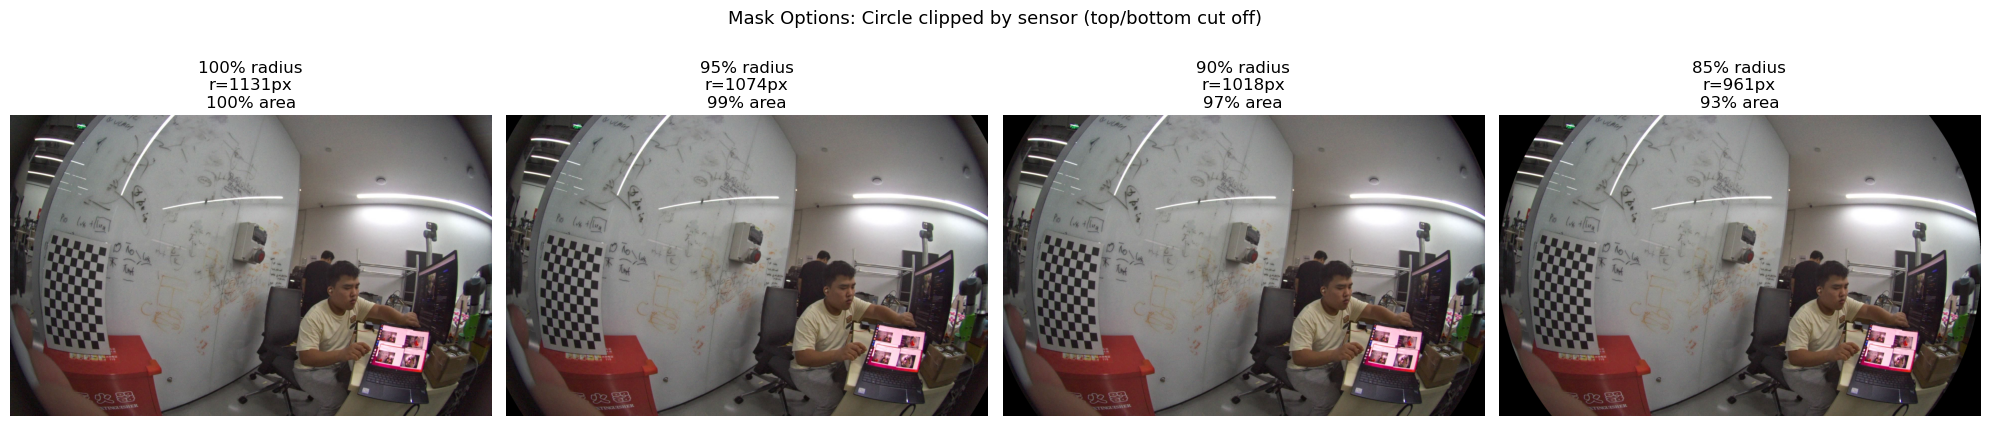

In [94]:
# Step 4: Create different mask options and visualize
# The mask is a circle (same as the FOV boundary), optionally shrunk for safety margin

# Mask options: 100%, 95%, 90% of detected radius
scale_options = [1.0, 0.95, 0.90, 0.85]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for idx, scale in enumerate(scale_options):
    r = int(radius_from_edges * scale)
    
    # Create circular mask
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask, (int(cx_cam), int(cy_cam)), r, 255, -1)
    
    # Apply mask
    masked_img = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
    
    # Count valid pixels
    valid_pct = np.sum(mask > 0) / mask.size * 100
    
    axes[idx].imshow(masked_img)
    axes[idx].set_title(f'{int(scale*100)}% radius\nr={r}px\n{valid_pct:.0f}% area')
    axes[idx].axis('off')

plt.suptitle('Mask Options: Circle clipped by sensor (top/bottom cut off)', fontsize=13)
plt.tight_layout()
plt.show()

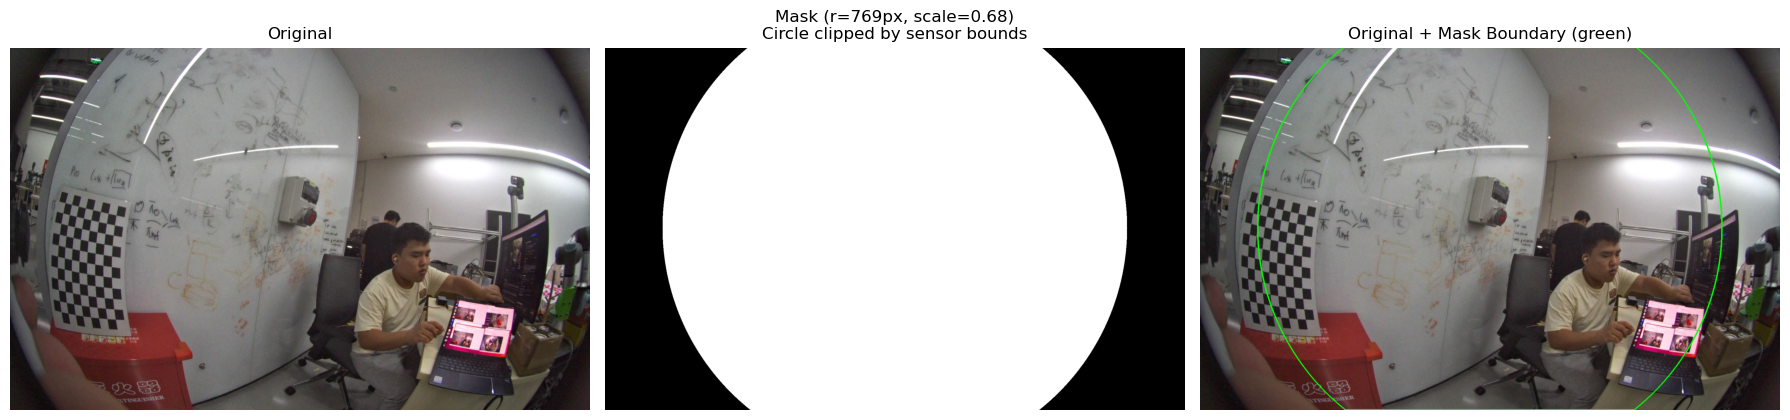

✅ Mask saved: /home/lhk/workspace/VINS-Fisheye/config/my_kalibr_fisheye/fisheye_mask.png
   Center: (959, 597)
   Radius: 769px (= 68% of detected 1131px)
   Valid pixels: 71.0% of image

   Note: The circle extends beyond top/bottom of sensor → mask is clipped to image bounds


In [95]:
# Step 5: Generate and save the final mask
# Using 95% of detected radius (removes noisy edge pixels)

mask_scale = 0.68
mask_radius = int(radius_from_edges * mask_scale)
mask_cx = int(cx_cam)
mask_cy = int(cy_cam)

# Create final mask: circle clipped by image bounds (naturally handles top/bottom cut)
fisheye_mask = np.zeros((h, w), dtype=np.uint8)
cv2.circle(fisheye_mask, (mask_cx, mask_cy), mask_radius, 255, -1)

# Save
mask_path = '/home/lhk/workspace/VINS-Fisheye/config/my_kalibr_fisheye/fisheye_mask.png'
cv2.imwrite(mask_path, fisheye_mask)

# Visualize final result side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(fisheye_mask, cmap='gray')
axes[1].set_title(f'Mask (r={mask_radius}px, scale={mask_scale})\nCircle clipped by sensor bounds')
axes[1].axis('off')

# Overlay: green boundary on original
vis = img_rgb.copy()
# Draw the mask boundary
contours_mask, _ = cv2.findContours(fisheye_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(vis, contours_mask, -1, (0, 255, 0), 3)
axes[2].imshow(vis)
axes[2].set_title('Original + Mask Boundary (green)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"✅ Mask saved: {mask_path}")
print(f"   Center: ({mask_cx}, {mask_cy})")
print(f"   Radius: {mask_radius}px (= {mask_scale*100:.0f}% of detected {radius_from_edges:.0f}px)")
print(f"   Valid pixels: {np.sum(fisheye_mask > 0) / fisheye_mask.size * 100:.1f}% of image")
print(f"\n   Note: The circle extends beyond top/bottom of sensor → mask is clipped to image bounds")

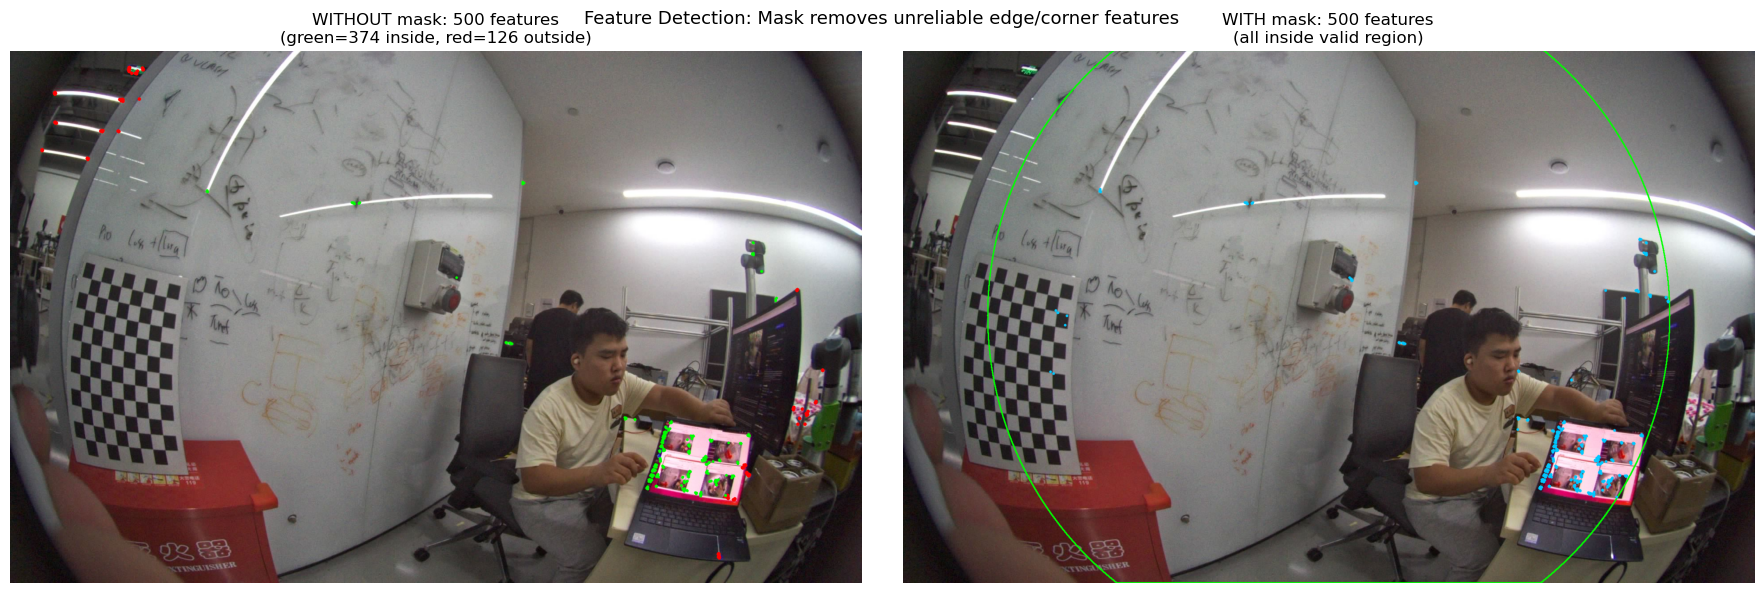


Without mask: 126 features in invalid region (25.2%)
With mask: all 500 features in valid region ✓


In [96]:
# Step 6: Verify - feature detection with/without mask

orb = cv2.ORB_create(nfeatures=500)

# Without mask
kp_no_mask = orb.detect(gray, None)

# With mask
kp_with_mask = orb.detect(gray, fisheye_mask)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Without mask - mark features outside circle in RED, inside in GREEN
vis1 = img_rgb.copy()
inside = 0
outside = 0
for kp in kp_no_mask:
    x, y = int(kp.pt[0]), int(kp.pt[1])
    dist = np.sqrt((x - mask_cx)**2 + (y - mask_cy)**2)
    if dist > mask_radius:
        cv2.circle(vis1, (x, y), 4, (255, 0, 0), -1)  # RED = outside
        outside += 1
    else:
        cv2.circle(vis1, (x, y), 3, (0, 255, 0), -1)  # GREEN = inside
        inside += 1
axes[0].imshow(vis1)
axes[0].set_title(f'WITHOUT mask: {len(kp_no_mask)} features\n(green={inside} inside, red={outside} outside)')
axes[0].axis('off')

# With mask
vis2 = img_rgb.copy()
# Draw mask boundary
cv2.drawContours(vis2, contours_mask, -1, (0, 255, 0), 2)
for kp in kp_with_mask:
    x, y = int(kp.pt[0]), int(kp.pt[1])
    cv2.circle(vis2, (x, y), 3, (0, 200, 255), -1)
axes[1].imshow(vis2)
axes[1].set_title(f'WITH mask: {len(kp_with_mask)} features\n(all inside valid region)')
axes[1].axis('off')

plt.suptitle('Feature Detection: Mask removes unreliable edge/corner features', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nWithout mask: {outside} features in invalid region ({100*outside/len(kp_no_mask):.1f}%)")
print(f"With mask: all {len(kp_with_mask)} features in valid region ✓")

# Step 7: Summary

The fisheye image has a **circular FOV** that is **vertically clipped** by the 1920x1200 sensor:
- Circle radius ≈ 960px (fills the full width)
- Top/bottom are cut off (sensor height 1200 < circle diameter ~1920)
- Four corners are BLACK (outside the circular FOV)

**Generated mask:** A circle at the optical center, shrunk to 95% to exclude noisy boundary pixels.
The mask is naturally clipped at image bounds (top/bottom), resulting in a "stadium" shape.

**Saved to:** `my_fisheye_stereo/fisheye_mask.png`